# Atelier 6 — CNN CIFAR-10

## Imports

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch.utils.tensorboard import SummaryWriter

KeyboardInterrupt: 

## Chargement de CIFAR-10

CIFAR-10 est un jeu de données de référence en apprentissage automatique, composé de 60 000 images couleur 32×32 pixels réparties en 10 classes (avion, voiture, oiseau, chat, cerf, chien, grenouille, cheval, bateau, camion).

La pipeline de transformation applique deux opérations :
- `ToTensor()` : convertit les images PIL (valeurs 0–255) en tenseurs PyTorch (valeurs 0.0–1.0)
- `Normalize(mean, std)` : centre et réduit chaque canal avec les statistiques de CIFAR-10, pour accélérer la convergence

In [ ]:
cifar10_mean = [0.4914, 0.4822, 0.4465]
cifar10_std  = [0.2470, 0.2435, 0.2616]

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=cifar10_mean, std=cifar10_std),
])

train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print(f"Train samples: {len(train_dataset)}")
print(f"Test samples:  {len(test_dataset)}")
print(f"Image shape:   {train_dataset[0][0].shape}")
print(f"Classes:       {train_dataset.classes}")

Train samples: 50000
Test samples:  10000
Image shape:   torch.Size([3, 32, 32])
Classes:       ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


On visualise quelques exemples pour comprendre à quoi ressemblent les données.

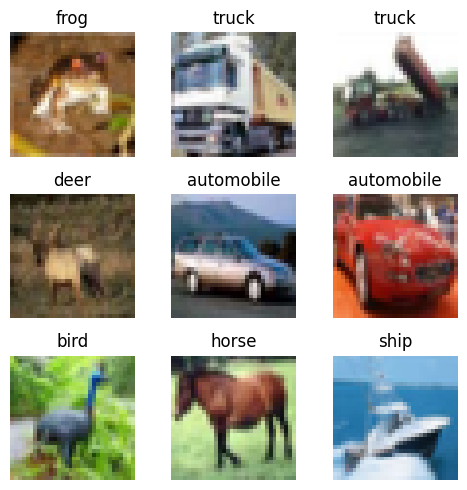

In [ ]:
mean = torch.tensor(cifar10_mean).view(3, 1, 1)
std  = torch.tensor(cifar10_std).view(3, 1, 1)

fig, axes = plt.subplots(3, 3, figsize=(5, 5))

for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]
    img = (img * std + mean).clamp(0, 1)  # dénormalisation
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(train_dataset.classes[label])
    ax.axis('off')

plt.tight_layout()
plt.show()

### DataLoader

Le `DataLoader` est un itérateur qui découpe le dataset en **mini-batches** et les mélange à chaque époque (`shuffle=True` pour l'entraînement).  
Ici un batch contient 64 images, chacune de forme `[3, 32, 32]` (3 canaux RGB, 32×32 pixels) → batch de forme `[64, 3, 32, 32]`.

In [ ]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=False)

train_features, train_labels = next(iter(train_dataloader))
train_features.size()

torch.Size([64, 3, 32, 32])

## Création du CNN

Un **CNN** (Convolutional Neural Network) est composé de deux parties :

- **Bloc convolutif** : extrait des features visuelles (bords, textures, formes) grâce à des filtres qui glissent sur l'image
- **Bloc fully-connected** : classifie l'image à partir de ces features, comme un MLP classique

Chaque bloc convolutif suit le même enchaînement :
1. `Conv2d` — applique des filtres locaux sur l'image
2. `BatchNorm2d` — normalise les valeurs pour stabiliser l'entraînement
3. `ReLU` — introduit de la non-linéarité (remplace les valeurs négatives par 0)
4. `MaxPool2d` — réduit la résolution par 2 en gardant le maximum de chaque fenêtre 2×2

On utilise 2 blocs convolutifs avec un doublement des filtres (32 → 64) pour compenser la réduction spatiale du pooling.

```
Entrée           [B,  3, 32, 32]   3 canaux RGB, images 32×32
Conv1 (3→32)     [B, 32, 32, 32]   32 filtres, padding=1 conserve la résolution
BatchNorm2d(32)  [B, 32, 32, 32]   normalise les 32 canaux
ReLU             [B, 32, 32, 32]
Pool ÷2          [B, 32, 16, 16]   résolution divisée par 2

Conv2 (32→64)    [B, 64, 16, 16]   64 filtres, features plus abstraites
BatchNorm2d(64)  [B, 64, 16, 16]   normalise les 64 canaux
ReLU             [B, 64, 16, 16]
Pool ÷2          [B, 64,  8,  8]   résolution divisée par 2

Flatten          [B,      4096]    64 × 8 × 8 = 4096 valeurs
Linear(4096→128) [B,       128]    couche cachée
ReLU             [B,       128]
Linear(128→10)   [B,        10]    un score par classe
```

In [ ]:
from torch import nn

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.conv_block1(x)   # [B, 32, 16, 16]
        x = self.conv_block2(x)   # [B, 64,  8,  8]
        x = self.classifier(x)    # [B, 10]
        return x

cnn = CNN()

In [ ]:
print(cnn)

n_params = sum(p.numel() for p in cnn.parameters() if p.requires_grad)
print(f"\nParamètres entraînables : {n_params:,}")

CNN(
  (conv_block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)

Paramètres entraînables : 545,290


In [ ]:
x_dummy = torch.randn(1, 3, 32, 32)
output = cnn(x_dummy)
print(f"Entrée : {x_dummy.shape} → Sortie : {output.shape}")
print(f"Scores : {output}")

Entrée : torch.Size([1, 3, 32, 32]) → Sortie : torch.Size([1, 10])
Scores : tensor([[-0.5618,  0.2199, -0.3318,  0.1185,  0.2480,  0.6995,  0.0038, -0.0570,
          0.1204,  0.3586]], grad_fn=<AddmmBackward0>)


## Entraînement

L'entraînement repose sur deux éléments :

- **Fonction de perte** (`CrossEntropyLoss`) : mesure l'écart entre la prédiction du modèle et la vraie étiquette. L'objectif est de la minimiser.
- **Optimiseur** (`AdamW`, lr=0.001) : met à jour les poids du réseau après chaque batch en suivant le gradient de la perte.

Deux mécanismes améliorent la convergence :
- **Scheduler** (`ReduceLROnPlateau`) : réduit le learning rate d'un facteur `factor` si la val loss ne s'améliore pas pendant `patience` époques consécutives, pour sortir des plateaux.
- **Early stopping** : arrête l'entraînement si la val loss ne s'améliore pas pendant `es_patience` époques, et restaure les meilleurs poids observés.

À chaque **époque** (passage complet sur le dataset) :
1. `train_loop` — le modèle apprend en ajustant ses poids via la rétropropagation
2. `test_loop` — le modèle est évalué sans mise à jour des poids (`torch.no_grad()`)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(cnn.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

In [ ]:
def train_loop(dataloader, model, loss_fn, optimizer, writer, epoch):
    model.train()
    pbar = tqdm(dataloader, desc="Train")
    for batch, (x, y_true) in enumerate(pbar):
        y_pred = model(x)
        loss = loss_fn(y_pred, y_true)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        pbar.set_postfix(loss=f"{loss.item():.4f}")
        writer.add_scalar("Loss/train", loss.item(), epoch * len(dataloader) + batch)

def test_loop(dataloader, model, loss_fn, writer, epoch):
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    with torch.no_grad():
        for x, y_true in tqdm(dataloader, desc="Test "):
            y_pred = model(x)
            test_loss += loss_fn(y_pred, y_true).item()
            correct += (y_pred.argmax(1) == y_true).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    print(f"Accuracy: {100 * correct:>0.1f}%, Avg loss: {test_loss:.6f}")

    writer.add_scalar("Loss/test", test_loss, epoch)
    writer.add_scalar("Accuracy/test", 100 * correct, epoch)

    return test_loss

In [ ]:
writer = SummaryWriter("runs/cnn_cifar10")

epochs = 20
es_patience = 5

best_loss = float("inf")
best_weights = None
epochs_without_improvement = 0

for t in range(epochs):
    print(f"Epoch : {t+1}  |  lr = {optimizer.param_groups[0]['lr']:.2e}")
    train_loop(train_dataloader, cnn, criterion, optimizer, writer, t)
    val_loss = test_loop(test_dataloader, cnn, criterion, writer, t)

    scheduler.step(val_loss)

    if val_loss < best_loss:
        best_loss = val_loss
        best_weights = {k: v.cpu().clone() for k, v in cnn.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        print(f"  (no improvement since {epochs_without_improvement} epoch(s))")
        if epochs_without_improvement >= es_patience:
            print(f"Early stopping triggered at epoch {t+1}.")
            break

cnn.load_state_dict(best_weights)
writer.close()
print("Done")

Epoch : 1  |  lr = 1.00e-03


Test : 100%|██████████| 157/157 [00:03<00:00, 41.08it/s]


Accuracy: 60.4%, Avg loss: 1.112518
Epoch : 2  |  lr = 1.00e-03


Test : 100%|██████████| 157/157 [00:03<00:00, 46.06it/s]


Accuracy: 66.3%, Avg loss: 0.976514
Epoch : 3  |  lr = 1.00e-03


...

Accuracy: 75.6%, Avg loss: 0.779318
  (no improvement since 2 epoch(s))
Epoch : 19  |  lr = 5.00e-04


Test : 100%|██████████| 157/157 [00:06<00:00, 24.78it/s]


Accuracy: 75.0%, Avg loss: 0.804028
  (no improvement since 3 epoch(s))
Epoch : 20  |  lr = 2.50e-04


Test : 100%|██████████| 157/157 [00:05<00:00, 29.65it/s]

Accuracy: 76.0%, Avg loss: 0.782881
  (no improvement since 4 epoch(s))
Done


## Export ONNX

On exporte le modèle entraîné au format **ONNX** (Open Neural Network Exchange), un format interopérable qui permet de déployer le modèle dans des runtimes comme `onnxruntime`, TensorRT, ou OpenVINO.

- `dynamic_axes` rend la dimension batch flexible à l'inférence
- `opset_version=17` est l'opset stable actuel
- Le modèle doit être en mode `eval()` pour figer BatchNorm et Dropout

In [ ]:
cnn.eval()
dummy_input = torch.randn(1, 3, 32, 32)

torch.onnx.export(
    cnn,
    dummy_input,
    "onnx/cnn_cifar10.onnx",
    input_names=["image"],
    output_names=["logits"],
    dynamic_axes={"image": {0: "batch_size"}, "logits": {0: "batch_size"}},
    opset_version=17,
)
print("Exported to cnn_cifar10.onnx")

NameError: name 'cnn' is not defined

In [ ]:
import onnx

model_onnx = onnx.load("onnx/cnn_cifar10.onnx")
onnx.checker.check_model(model_onnx)
print("ONNX model is valid")
print(f"Opset version: {model_onnx.opset_import[0].version}")
print(f"Inputs:  {[i.name for i in model_onnx.graph.input]}")
print(f"Outputs: {[o.name for o in model_onnx.graph.output]}")